<a href="https://colab.research.google.com/github/cathrineq/python-ai-Tarasova-Kate/blob/main/notebooks/viz1_currency_clusters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование и загрузка

**Что делаем:**
- Клонируем репозиторий `python-ai-Tarasova-Kate` в Colab
- Загружаем 2 CSV-файла из Wikidata:
  - `currency_rates.csv` — курсы валют (P2284) с метками времени (P585, P580)
  - `countries_currencies.csv` — страны + официальные валюты (P38, P1082, P2046)
- Очищаем данные:
  - 🔗 URL Wikidata → переименовываем (`URL`, `country_URL`, `currency_URL`) — **не удаляем!**
  - 🏷️ `*Label` → короткие имена (`currency`, `unit`, `country`)
  - 📊 Числовые поля → `float`, пропуски (`NaN`) **не заменяем на 0**
  - 📈 Измеряем заполненность `OPTIONAL`-полей перед очисткой

**Результат:**

📊 `df_rates` — курсы валют по времени
| Столбец | Описание |
|---------|----------|
| `URL` | Ссылка на валюту в Wikidata 🔑 |
| `currency` | Название валюты |
| `price` | Курс в евро (float, возможны NaN) |
| `year` / `startYear` | Год данных (float, возможны NaN) |
| `unit` / `unitSymbol` | Единица измерения и символ |

🌍 `df_countries` — страны и их валюты
| Столбец | Описание |
|---------|----------|
| `country_URL` | Ссылка на страну в Wikidata |
| `country` | Название страны |
| `currency_URL` | Ссылка на валюту 🔑 (ключ для `merge`) |
| `currency` | Название валюты |
| `population` / `area` | Население и площадь (float, возможны NaN) |

> 💡 **Важно:** Столбцы `URL` / `currency_URL` сохранены для:  
> 1) отладки аномалий (клик → запись в Wikidata)  
> 2) надёжного объединения таблиц через `pd.merge(on="currency_URL")`

In [1]:
# ============================================================
#  ЯЧЕЙКА 1: Подготовка данных (для viz1 и viz2)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Клонируем репозиторий (если ещё не клонирован)
repo = "python-ai-Tarasova-Kate"
repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/cathrineq/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

# 2. Загружаем сырые CSV-файлы
df_rates_raw = pd.read_csv("data/currency_rates.csv")
df_countries_raw = pd.read_csv("data/countries_currencies.csv")

# 3. Очистка и переименование столбцов для df_rates (как в задании 2)
df_rates = df_rates_raw.rename(columns={
    "currency": "URL",
    "currencyLabel": "currency",
    "unitLabel": "unit"
}, errors="ignore")

# Приводим числовые столбцы к float (NaN, если не число)
df_rates["price"] = pd.to_numeric(df_rates["price"], errors="coerce")
if "year" in df_rates.columns:
    df_rates["year"] = pd.to_numeric(df_rates["year"], errors="coerce")
if "startYear" in df_rates.columns:
    df_rates["startYear"] = pd.to_numeric(df_rates["startYear"], errors="coerce")

# 4. Очистка для df_countries (переименовываем URL и Label)
df_countries = df_countries_raw.rename(columns={
    "country": "country_URL",
    "currency": "currency_URL",
    "countryLabel": "country",
    "currencyLabel": "currency"
}, errors="ignore")

# Приводим числовые столбцы
df_countries["population"] = pd.to_numeric(df_countries["population"], errors="coerce")
df_countries["area"] = pd.to_numeric(df_countries["area"], errors="coerce")

# 5. Документируем выбросы по цене (очень большие значения)
outliers = df_rates[df_rates["price"] >= 1e8]  # 100 миллионов и больше
if len(outliers) > 0:
    print("⚠️ ВНИМАНИЕ: Обнаружены выбросы по цене (≥ 100 000 000 евро):")
    print(outliers[["URL", "currency", "price", "year", "unit"]].to_string())
    print("\nЭти выбросы могут искажать цветовую шкалу на графиках.")
    print("В viz1 мы их временно исключим (оставим только цены < 1e8).\n")
else:
    print("✅ Выбросов по цене не обнаружено.\n")

# 6. Создаём df_unique_countries (уникальные страны, агрегированные)
#    Это нужно для второй визуализации (карта с дугами), но можно создать сразу.
df_unique_countries = (
    df_countries
    .groupby("country_URL")
    .agg(
        country=("country", "first"),               # название страны
        n_currencies=("currency_URL", "nunique"),  # сколько разных валют было у страны
        population=("population", "max"),          # население (берём максимум, если несколько записей)
        area=("area", "max")                       # площадь
    )
    .reset_index()
)
print(f"✅ df_unique_countries: {len(df_unique_countries)} уникальных стран (из {len(df_countries)} строк)")

# 7. Краткая информация о данных (для проверки)
print("\n📊 df_rates:", df_rates.shape)
print("Столбцы:", df_rates.columns.tolist())
print("\n📊 df_countries:", df_countries.shape)
print("Столбцы:", df_countries.columns.tolist())
print("\n✅ Подготовка данных завершена.")

/content/python-ai-Tarasova-Kate
⚠️ ВНИМАНИЕ: Обнаружены выбросы по цене (≥ 100 000 000 евро):
                                           URL            currency         price    year                   unit
523   http://www.wikidata.org/entity/Q56349362  Суверенный боливар  1.000000e+08  2018.0  венесуэльский боливар
526   http://www.wikidata.org/entity/Q56349362  Суверенный боливар  1.000000e+08  2018.0  венесуэльский боливар
529   http://www.wikidata.org/entity/Q56349362  Суверенный боливар  1.000000e+08  2018.0  венесуэльский боливар
1417    http://www.wikidata.org/entity/Q260447       рентная марка  1.000000e+09  1923.0             рейхсмарка

Эти выбросы могут искажать цветовую шкалу на графиках.
В viz1 мы их временно исключим (оставим только цены < 1e8).

✅ df_unique_countries: 209 уникальных стран (из 803 строк)

📊 df_rates: (2346, 8)
Столбцы: ['URL', 'currency', 'shortName', 'price', 'year', 'startYear', 'unit', 'unitSymbol']

📊 df_countries: (803, 7)
Столбцы: ['country_URL', '

#🌟Кластеризованная тепловая карта (clustermap)


До фильтрации выбросов: 232 записей
Исключено выбросов: 0
Осталось записей для анализа: 232
Размер сводной таблицы: (20, 9) (валюты × временные интервалы)


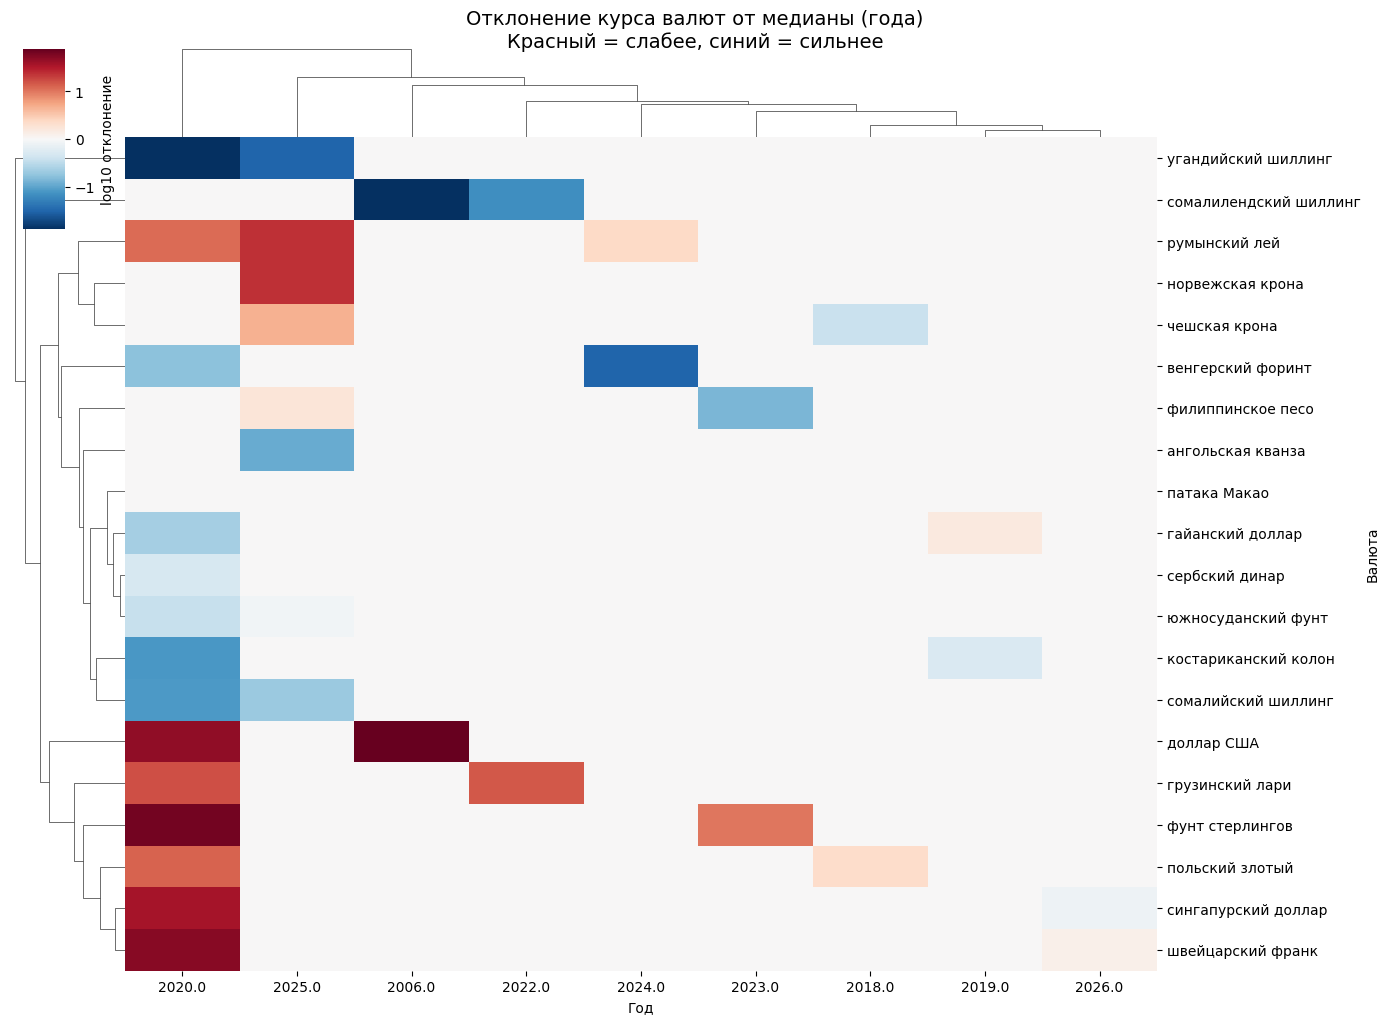


✅ Кластеризация выполнена.
Слева от тепловой карты – дендрограмма, которая группирует валюты со схожей динамикой.
Попробуйте менять настройки USE_DECADES, USE_DEVIATION, REMOVE_OUTLIERS и смотреть, как меняется картина.


In [7]:
# ============================================================
#  ЯЧЕЙКА 2: Clustermap – кластеризация валют по динамике курса
# ============================================================

# Настройки (меняйте True/False и смотрите, как меняется график)
USE_DECADES = False
USE_DEVIATION = True
REMOVE_OUTLIERS = True

# 1. Фильтруем только курсы в евро с известным годом и положительной ценой
df_eur = df_rates[
    (df_rates["unit"] == "евро") &
    (df_rates["year"].notna()) &
    (df_rates["price"].notna()) &
    (df_rates["price"] > 0)
].copy()

print(f"До фильтрации выбросов: {len(df_eur)} записей")

# 2. Исключаем выбросы, если нужно
if REMOVE_OUTLIERS:
    before = len(df_eur)
    df_eur = df_eur[df_eur["price"] < 1e8]   # убираем цены >= 100 млн
    print(f"Исключено выбросов: {before - len(df_eur)}")
else:
    print("Выбросы не исключены (будут видны на графике)")

print(f"Осталось записей для анализа: {len(df_eur)}")

# 3. Логарифмируем цену
df_eur["log_price"] = np.log10(df_eur["price"])

# 4. Создаём временные интервалы (десятилетия или годы)
if USE_DECADES:
    df_eur["time_bin"] = (df_eur["year"] // 10 * 10).astype(int)
    time_label = "Десятилетие"
else:
    df_eur["time_bin"] = df_eur["year"]
    time_label = "Год"

# 5. Строим сводную таблицу: строки = валюта, столбцы = время, значения = средний log_price
pivot = df_eur.pivot_table(
    index="currency",
    columns="time_bin",
    values="log_price",
    aggfunc="mean"
)

# Удаляем валюты, у которых слишком мало наблюдений (менее 2 временных точек)
min_periods = 2
pivot = pivot.dropna(thresh=min_periods, axis=0)

# Удаляем временные интервалы, где менее 2 валют
pivot = pivot.dropna(thresh=2, axis=1)

print(f"Размер сводной таблицы: {pivot.shape} (валюты × временные интервалы)")

if pivot.shape[0] < 2 or pivot.shape[1] < 2:
    raise ValueError("Слишком мало данных для кластеризации. Попробуйте уменьшить min_periods или сменить настройки.")

# 6. Нормализация (отклонение от медианы или абсолютные значения)
if USE_DEVIATION:
    # Вычитаем медиану по каждому временному интервалу
    pivot_norm = pivot.sub(pivot.median(axis=0), axis=1)
    cmap = "RdBu_r"
    center = 0
    title = f"Отклонение курса валют от медианы ({'десятилетия' if USE_DECADES else 'года'})\nКрасный = слабее, синий = сильнее"
    cbar_label = "log10 отклонение"
else:
    pivot_norm = pivot
    cmap = "viridis"
    center = None
    title = f"Абсолютный логарифм курса валют к евро\n({'десятилетия' if USE_DECADES else 'годы'})"
    cbar_label = "log10(price)"

# Заменяем пропуски (NaN) на 0 – это означает, что значение равно медиане (для отклонения)
pivot_norm = pivot_norm.fillna(0)
# Заменяем бесконечности (если вдруг) на 0
pivot_norm = pivot_norm.replace([np.inf, -np.inf], 0)

# 7. Строим кластеризованную тепловую карту
g = sns.clustermap(
    pivot_norm,
    cmap=cmap,
    center=center,
    figsize=(14, 10),
    col_cluster=True,      # группировать похожие временные интервалы
    row_cluster=True,      # группировать похожие валюты
    dendrogram_ratio=0.1,
    cbar_pos=(0.02, 0.8, 0.03, 0.18),
    cbar_kws={"label": cbar_label}
)

# Настройка подписей осей и заголовка
g.ax_heatmap.set_xlabel(time_label)
g.ax_heatmap.set_ylabel("Валюта")
g.fig.suptitle(title, y=1.02, fontsize=14)

# Показываем график
plt.show()

print("\n✅ Кластеризация выполнена.")
print("Слева от тепловой карты – дендрограмма, которая группирует валюты со схожей динамикой.")
print("Попробуйте менять настройки USE_DECADES, USE_DEVIATION, REMOVE_OUTLIERS и смотреть, как меняется картина.")